This notebook trains a random forest model to predict the binning label of each image based on the features extracted from the cell profiling pipeline. 
The model is trained on a balanced dataset, where each binning label is represented equally. 
The dataset is split into training, validation, and test sets, and the model's performance is evaluated on the test set.
The predicted bins are used to adjust the segmentation parameters for each image, which is expected to improve the segmentation quality.

In [1]:
import argparse
import json
import os
import pathlib
import sys
import time

import joblib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import seaborn as sns
import tifffile
from arg_parsing_utils import check_for_missing_args, parse_args
from file_reading import *
from file_reading import read_zstack_image
from notebook_init_utils import bandicoot_check, init_notebook
from skimage.filters import sobel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
def read_labels(infile: str) -> dict:
    """
    Description
    ----------
    Read labels from a parquet file.
    Parameters
    ----------
    infile : str
        Path to the input parquet file.
    Returns
    -------
    dict
        Dictionary containing the labels.
    """
    data = pd.read_parquet(infile).to_dict(orient="list")
    return data

In [3]:
start_time = time.time()
# get starting memory (cpu)
start_mem = psutil.Process(os.getpid()).memory_info().rss / 1024**2

In [4]:
root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot/NF1_organoid_data")).resolve(),
    root_dir,
)
patient_list_file_path = pathlib.Path(f"{root_dir}/data/patient_IDs.txt").resolve(
    strict=True
)
raw_image_base_dir = pathlib.Path(f"{image_base_dir}/data/").resolve()

In [5]:
labels_save_file = pathlib.Path(
    "../image_labels/segmentation_classes.parquet"
).resolve()
annotations_save_file = pathlib.Path("../image_labels/annotations.parquet").resolve()
all_features_save_path = pathlib.Path(f"../results/all_features.parquet").resolve(
    strict=True
)
labels = read_labels(annotations_save_file)
labels_df = pd.DataFrame(labels)
print(labels_df.shape)
labels_df.head()

(3734, 7)


,patient,well_fov,label_name,image_filename,annotator,label,timestamp
0,NF0014_T1,F11-2,dissociated,NF0014_T1_F11-2_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811
1,NF0014_T1,F10-1,dissociated,NF0014_T1_F10-1_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811
2,NF0014_T1,D6-1,globular,NF0014_T1_D6-1_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
3,NF0014_T1,G5-2,globular,NF0014_T1_G5-2_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
4,NF0014_T1,F6-1,globular,NF0014_T1_F6-1_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811


In [6]:
all_features_df = pd.read_parquet(all_features_save_path)
all_features_df
df = pd.merge(
    all_features_df,
    labels_df,
    on=["patient", "well_fov"],
    how="right",
)
df

,patient,well_fov,405_CHAMMI75_feature_0,405_CHAMMI75_feature_1,405_CHAMMI75_feature_10,405_CHAMMI75_feature_100,405_CHAMMI75_feature_101,405_CHAMMI75_feature_102,405_CHAMMI75_feature_103,405_CHAMMI75_feature_104,...,TRANS_SAMMed3D_feature_95,TRANS_SAMMed3D_feature_96,TRANS_SAMMed3D_feature_97,TRANS_SAMMed3D_feature_98,TRANS_SAMMed3D_feature_99,label_name,image_filename,annotator,label,timestamp
0,NF0014_T1,F11-2,-0.107668,-1.988193,0.430800,-5.042886,6.411124,4.670228,-4.214027,-6.439321,...,-0.076290,0.057589,0.151462,0.425683,0.095404,dissociated,NF0014_T1_F11-2_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811
1,NF0014_T1,F10-1,2.428832,-1.633864,-0.825408,-5.890157,4.340623,0.974321,-2.225564,-3.561536,...,-0.051768,0.060354,0.187309,0.404193,0.136707,dissociated,NF0014_T1_F10-1_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811
2,NF0014_T1,D6-1,1.213292,-5.476718,1.314242,-2.165800,2.794735,1.713934,-2.744822,0.393758,...,-0.091618,0.052711,0.139284,0.460049,0.104861,globular,NF0014_T1_D6-1_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
3,NF0014_T1,G5-2,0.464782,-0.603957,-0.271298,-4.181277,4.592072,6.267917,-4.073701,-4.248343,...,-0.128131,0.045006,0.139317,0.456540,0.095817,globular,NF0014_T1_G5-2_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
4,NF0014_T1,F6-1,3.719172,-3.772722,1.645185,-2.687943,2.719582,0.815857,-2.967998,-0.592468,...,-0.079215,0.050384,0.137747,0.456838,0.102471,globular,NF0014_T1_F6-1_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3729,SARCO361_T1,D5-2,-1.635967,0.437740,0.546358,-2.933022,5.236318,6.088900,-3.654223,-5.646816,...,-0.059996,0.054254,0.151173,0.425260,0.099692,cluster,SARCO361_T1_D5-2_555_downsampled.png,Mike,6,2026-02-11 15:52:08.348811
3730,SARCO361_T1,G7-3,-0.932902,-0.668128,1.266262,-2.541597,2.741138,6.342504,-3.413855,-6.312388,...,-0.081506,0.047079,0.142173,0.435752,0.087813,cluster,SARCO361_T1_G7-3_555_downsampled.png,Mike,6,2026-02-11 15:52:08.348811
3731,SARCO361_T1,E9-3,-0.068021,0.953469,0.457139,-2.684773,4.226796,5.943666,-5.771163,-6.761784,...,-0.077567,0.049160,0.148637,0.448016,0.107186,cluster,SARCO361_T1_E9-3_555_downsampled.png,Mike,6,2026-02-11 15:52:08.348811
3732,SARCO361_T1,E10-6,-0.541575,1.146327,1.030575,-0.782875,3.791331,6.865782,-4.474011,-6.077713,...,-0.085136,0.052853,0.140063,0.450267,0.098372,cluster,SARCO361_T1_E10-6_555_downsampled.png,Mike,6,2026-02-11 15:52:08.348811


In [7]:
# drop rows with na
df = df.dropna(subset=["label_name"])
# drop the failed labels
df = df[df["label_name"] != "fail"]
# drop the blank labels
df = df[df["label_name"] != "blank"]
# drop na
df = df.dropna()
print(df.shape)
df.head()

(3003, 3847)


,patient,well_fov,405_CHAMMI75_feature_0,405_CHAMMI75_feature_1,405_CHAMMI75_feature_10,405_CHAMMI75_feature_100,405_CHAMMI75_feature_101,405_CHAMMI75_feature_102,405_CHAMMI75_feature_103,405_CHAMMI75_feature_104,...,TRANS_SAMMed3D_feature_95,TRANS_SAMMed3D_feature_96,TRANS_SAMMed3D_feature_97,TRANS_SAMMed3D_feature_98,TRANS_SAMMed3D_feature_99,label_name,image_filename,annotator,label,timestamp
0,NF0014_T1,F11-2,-0.107668,-1.988193,0.430800,-5.042886,6.411124,4.670228,-4.214027,-6.439321,...,-0.076290,0.057589,0.151462,0.425683,0.095404,dissociated,NF0014_T1_F11-2_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811
1,NF0014_T1,F10-1,2.428832,-1.633864,-0.825408,-5.890157,4.340623,0.974321,-2.225564,-3.561536,...,-0.051768,0.060354,0.187309,0.404193,0.136707,dissociated,NF0014_T1_F10-1_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811
2,NF0014_T1,D6-1,1.213292,-5.476718,1.314242,-2.165800,2.794735,1.713934,-2.744822,0.393758,...,-0.091618,0.052711,0.139284,0.460049,0.104861,globular,NF0014_T1_D6-1_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
3,NF0014_T1,G5-2,0.464782,-0.603957,-0.271298,-4.181277,4.592072,6.267917,-4.073701,-4.248343,...,-0.128131,0.045006,0.139317,0.456540,0.095817,globular,NF0014_T1_G5-2_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811
4,NF0014_T1,F6-1,3.719172,-3.772722,1.645185,-2.687943,2.719582,0.815857,-2.967998,-0.592468,...,-0.079215,0.050384,0.137747,0.456838,0.102471,globular,NF0014_T1_F6-1_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811


In [8]:
# holdout a single patient
holdout_patients = ["NF0021_T1", "NF0030_T1"]
holdout_df = df[df["patient"].isin(holdout_patients)]
# drop the holdout patient from the main df
df = df[~df["patient"].isin(holdout_patients)]
# set up data splits
# train: 80%, val: 10%, test: 10%
# stratify by label, patient

train_df, test_df = train_test_split(
    df,
    test_size=0.10,
    random_state=0,
    stratify=df[["label_name"]],
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1111,  # 0.1111 * 0.90 = 0.10 (10% test)
    random_state=0,
    stratify=train_df[["label_name"]],
)
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")
print(f"Holdout size: {len(holdout_df)}")
if len(train_df) + len(val_df) + len(test_df) + len(holdout_df) != len(df) + len(
    holdout_df
):
    raise ValueError("Data split sizes do not add up to total dataset size.")

Train size: 1960
Validation size: 245
Test size: 245
Holdout size: 553


In [9]:
non_feature_cols = [
    "patient",
    "well_fov",
    "label_name",
    "image_filename",
    "annotator",
    "label",
    "timestamp",
]

In [10]:
# fit the train data to the z score normalization


scaler = StandardScaler()
feature_cols = train_df.drop(columns=non_feature_cols).columns

# Fit scaler on training features only
scaler.fit(train_df[feature_cols])

# Transform each split and reconstruct DataFrames
train_scaled = pd.DataFrame(
    scaler.transform(train_df[feature_cols]), columns=feature_cols, index=train_df.index
)
train_df = pd.concat([train_df[non_feature_cols], train_scaled], axis=1)

val_scaled = pd.DataFrame(
    scaler.transform(val_df[feature_cols]), columns=feature_cols, index=val_df.index
)
val_df = pd.concat([val_df[non_feature_cols], val_scaled], axis=1)

test_scaled = pd.DataFrame(
    scaler.transform(test_df[feature_cols]), columns=feature_cols, index=test_df.index
)
test_df = pd.concat([test_df[non_feature_cols], test_scaled], axis=1)

holdout_scaled = pd.DataFrame(
    scaler.transform(holdout_df[feature_cols]),
    columns=feature_cols,
    index=holdout_df.index,
)
holdout_df = pd.concat([holdout_df[non_feature_cols], holdout_scaled], axis=1)

In [11]:
# train a multi-class logistic regression model for the organoid labels

log_reg_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=0,
)
rf_model = RandomForestClassifier(n_estimators=1000, random_state=0)


log_reg_model.fit(
    train_df.drop(columns=non_feature_cols),
    train_df["label_name"],
)
rf_model.fit(
    train_df.drop(columns=non_feature_cols),
    train_df["label_name"],
)

# save the models
joblib.dump(log_reg_model, "../models/logistic_regression_model.joblib")
joblib.dump(rf_model, "../models/random_forest_model.joblib")

['../models/random_forest_model.joblib']

In [12]:
# log reg preds
train_log_reg_preds = log_reg_model.predict(train_df.drop(columns=non_feature_cols))

val_log_reg_preds = log_reg_model.predict(val_df.drop(columns=non_feature_cols))

test_log_reg_preds = log_reg_model.predict(test_df.drop(columns=non_feature_cols))
holdout_log_reg_preds = log_reg_model.predict(holdout_df.drop(columns=non_feature_cols))

# rf preds
train_rf_preds = rf_model.predict(train_df.drop(columns=non_feature_cols))
val_rf_preds = rf_model.predict(val_df.drop(columns=non_feature_cols))
test_rf_preds = rf_model.predict(test_df.drop(columns=non_feature_cols))
holdout_rf_preds = rf_model.predict(holdout_df.drop(columns=non_feature_cols))

In [13]:
label_names = {
    1: "globular",
    2: "small",
    3: "dissociated",
    4: "elongated",
    5: "blank",
    6: "cluster",
    7: "fail",
}

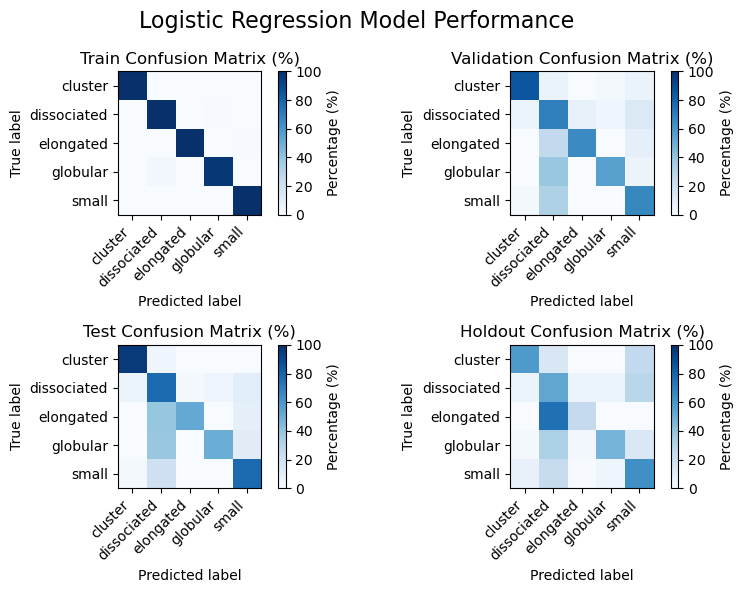

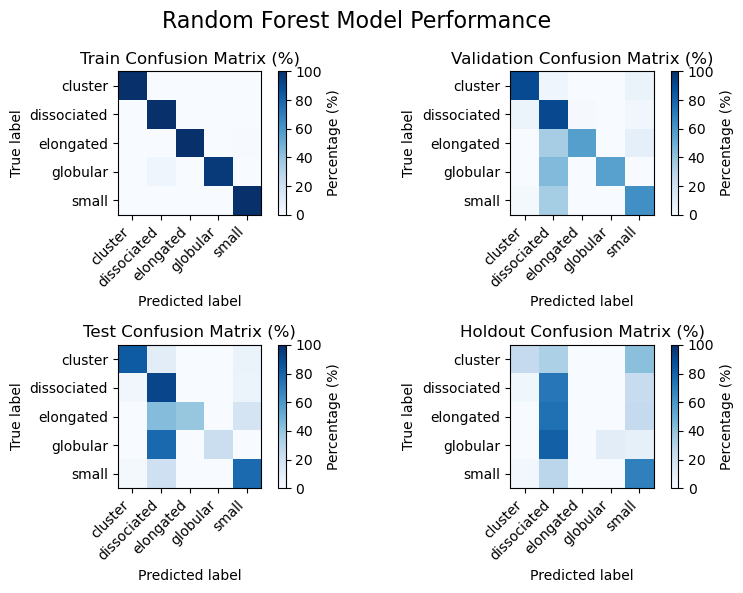

In [14]:
############################################
# Logistic Regression Model Performance
############################################

# plot the confusion matrix for the validation set (row-normalized to percentages)
plt.figure(figsize=(8, 6))
# add a figure title for the whole figure
plt.suptitle("Logistic Regression Model Performance", fontsize=16)
# train - val - test - holdout
############################################

# train
plt.subplot(2, 2, 1)
labels_in_train = np.sort(train_df["label_name"].unique())
cm = confusion_matrix(
    train_df["label_name"], train_log_reg_preds, labels=labels_in_train
)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Train Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

tick_marks = np.arange(len(labels_in_train))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_train]
plt.xticks(np.arange(len(tick_labels)), tick_labels, rotation=45, ha="right")
plt.yticks(np.arange(len(tick_labels)), tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
############################################
# validation
plt.subplot(2, 2, 2)
labels_in_val = np.sort(val_df["label_name"].unique())
cm = confusion_matrix(val_df["label_name"], val_log_reg_preds, labels=labels_in_val)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Validation Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

tick_marks = np.arange(len(labels_in_val))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_val]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
############################################
# test
plt.subplot(2, 2, 3)
labels_in_test = np.sort(test_df["label_name"].unique())
cm = confusion_matrix(test_df["label_name"], test_log_reg_preds, labels=labels_in_test)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Test Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")
tick_marks = np.arange(len(labels_in_test))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_test]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
############################################
# holdout
plt.subplot(2, 2, 4)
labels_in_holdout = np.sort(holdout_df["label_name"].unique())
cm = confusion_matrix(
    holdout_df["label_name"], holdout_log_reg_preds, labels=labels_in_holdout
)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Holdout Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")
tick_marks = np.arange(len(labels_in_holdout))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_holdout]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

############################################
# Random Forrest Model Performance
############################################

# plot the confusion matrix for the validation set (row-normalized to percentages)
plt.figure(figsize=(8, 6))
plt.suptitle("Random Forest Model Performance", fontsize=16)
# train - val - test - holdout
############################################

# train
plt.subplot(2, 2, 1)
labels_in_train = np.sort(train_df["label_name"].unique())
cm = confusion_matrix(train_df["label_name"], train_rf_preds, labels=labels_in_train)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Train Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

tick_marks = np.arange(len(labels_in_train))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_train]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
############################################
# validation
plt.subplot(2, 2, 2)
labels_in_val = np.sort(val_df["label_name"].unique())
cm = confusion_matrix(val_df["label_name"], val_rf_preds, labels=labels_in_val)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Validation Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

tick_marks = np.arange(len(labels_in_val))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_val]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
############################################
# test
plt.subplot(2, 2, 3)
labels_in_test = np.sort(test_df["label_name"].unique())
cm = confusion_matrix(test_df["label_name"], test_rf_preds, labels=labels_in_test)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Test Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")
tick_marks = np.arange(len(labels_in_test))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_test]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
############################################
# holdout
plt.subplot(2, 2, 4)
labels_in_holdout = np.sort(holdout_df["label_name"].unique())
cm = confusion_matrix(
    holdout_df["label_name"], holdout_rf_preds, labels=labels_in_holdout
)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=100)
plt.title("Holdout Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")
tick_marks = np.arange(len(labels_in_holdout))
tick_labels = [label_names.get(l, str(l)) for l in labels_in_holdout]
plt.xticks(tick_marks, tick_labels, rotation=45, ha="right")
plt.yticks(tick_marks, tick_labels)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [15]:
# concatenate the train, val, test df with the predections

train_out = train_df.assign(split="train", log_reg_prediction=train_log_reg_preds)
val_out = val_df.assign(split="val", log_reg_prediction=val_log_reg_preds)
test_out = test_df.assign(split="test", log_reg_prediction=test_log_reg_preds)
holdout_out = holdout_df.assign(
    split="holdout", log_reg_prediction=holdout_log_reg_preds
)

train_out = train_out.assign(split="train", rf_prediction=train_rf_preds)
val_out = val_out.assign(split="val", rf_prediction=val_rf_preds)
test_out = test_out.assign(split="test", rf_prediction=test_rf_preds)
holdout_out = holdout_out.assign(split="holdout", rf_prediction=holdout_rf_preds)

all_preds_df = pd.concat([train_out, val_out, test_out, holdout_out], ignore_index=True)
all_preds_df["image_path"] = all_preds_df.apply(
    lambda row: pathlib.Path(
        f"{raw_image_base_dir}/{row['patient']}/zstack_images/"
        f"{row['well_fov']}/{row['well_fov']}_555.tif"
    ).resolve(),
    axis=1,
)
all_preds_df.head()

,patient,well_fov,label_name,image_filename,annotator,label,timestamp,405_CHAMMI75_feature_0,405_CHAMMI75_feature_1,405_CHAMMI75_feature_10,...,TRANS_SAMMed3D_feature_94,TRANS_SAMMed3D_feature_95,TRANS_SAMMed3D_feature_96,TRANS_SAMMed3D_feature_97,TRANS_SAMMed3D_feature_98,TRANS_SAMMed3D_feature_99,split,log_reg_prediction,rf_prediction,image_path
0,SARCO361_T1,C10-7,small,SARCO361_T1_C10-7_555_downsampled.png,Mike,2,2026-02-11 15:52:08.348811,-0.696533,1.072219,-0.292352,...,-0.424742,-0.205738,-0.319427,-0.488153,0.161422,-0.571809,train,small,small,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
1,NF0040_T1,C9-7,dissociated,NF0040_T1_C9-7_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811,0.099495,-0.480349,-0.129474,...,1.141028,1.057237,0.312963,2.514903,-0.411329,1.956214,train,dissociated,dissociated,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
2,NF0035_T1,E5-5,globular,NF0035_T1_E5-5_555_downsampled.png,Mike,1,2026-02-11 15:52:08.348811,1.231602,0.018884,1.465094,...,-0.639816,0.304745,0.402905,-0.030883,0.447500,0.140093,train,globular,globular,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
3,NF0035_T1,D11-2,dissociated,NF0035_T1_D11-2_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811,0.066433,-1.324444,-0.365464,...,-0.342931,-0.600744,0.479600,0.144934,0.532657,0.061409,train,dissociated,dissociated,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
4,NF0037_T1,C7-7,dissociated,NF0037_T1_C7-7_555_downsampled.png,Mike,3,2026-02-11 15:52:08.348811,1.154419,-0.631185,-1.489897,...,0.528493,0.565057,-0.317755,-0.380756,-0.285722,-0.194811,train,dissociated,dissociated,/home/lippincm/mnt/bandicoot/NF1_organoid_data...


In [16]:
# calculate the model-wise per split performance metrics
performance_metrics = []
for model in ["log_reg_prediction", "rf_prediction"]:
    for split in ["train", "val", "test", "holdout"]:
        subset_df = all_preds_df[all_preds_df["split"] == split].copy()
        y_true = subset_df["label_name"]
        y_pred = subset_df[model]
        balanced_acc = balanced_accuracy_score(y_true, y_pred)
        performance_metrics.append(
            {
                "model": model,
                "split": split,
                "balanced_accuracy": balanced_acc,
            }
        )
performance_metrics_df = pd.DataFrame(performance_metrics)
performance_metrics_df

,model,split,balanced_accuracy
0,log_reg_prediction,train,0.992123
1,log_reg_prediction,val,0.682935
2,log_reg_prediction,test,0.706172
3,log_reg_prediction,holdout,0.495223
4,rf_prediction,train,0.989856
5,rf_prediction,val,0.709979
6,rf_prediction,test,0.627189
7,rf_prediction,holdout,0.353365


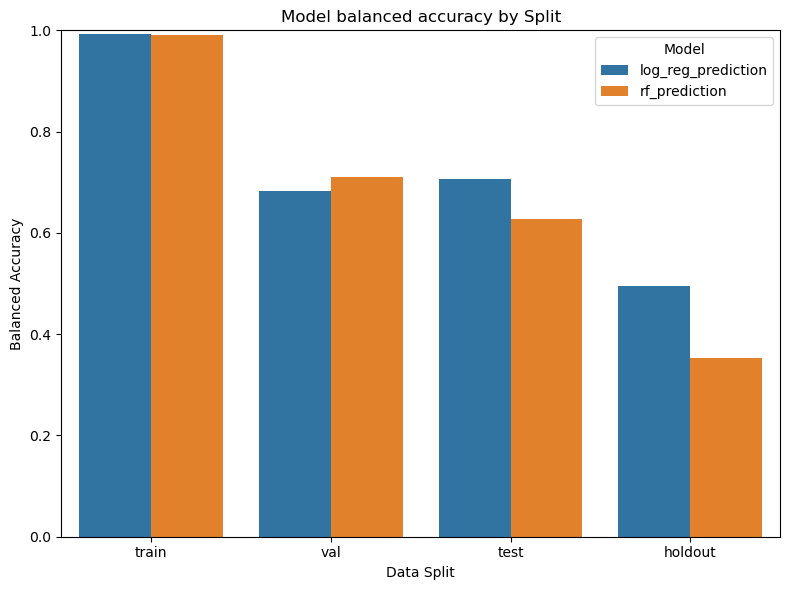

In [17]:
# plot the accuracy for each split with each model as a different color
# split bar plot
plt.figure(figsize=(8, 6))
plt.title("Model balanced accuracy by Split")
sns.barplot(data=performance_metrics_df, x="split", y="balanced_accuracy", hue="model")
plt.ylim(0, 1)
plt.ylabel("Balanced Accuracy")
plt.xlabel("Data Split")
plt.legend(title="Model", loc="upper right")
plt.tight_layout()
plt.show()

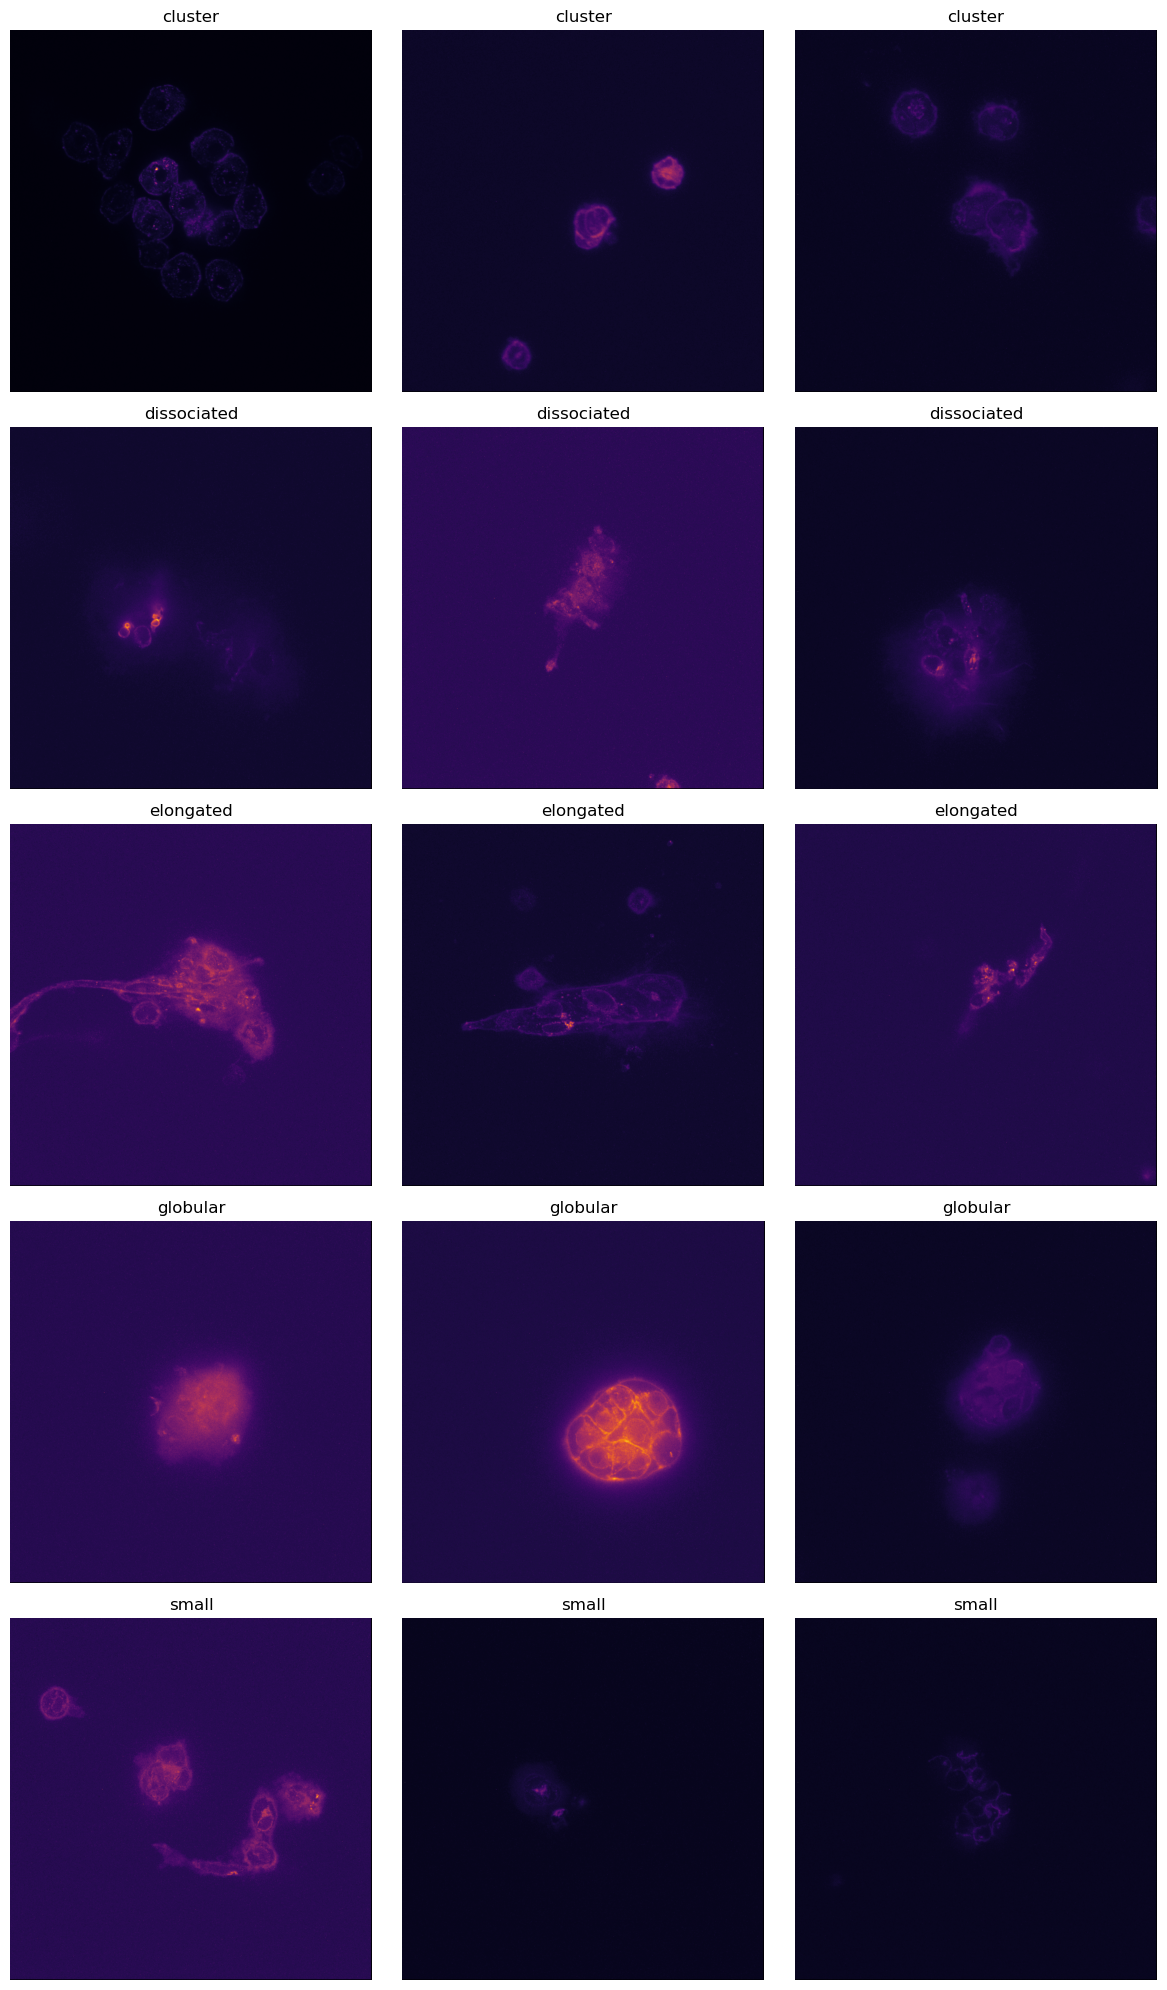

In [18]:
# pick three random images from each predicted class to show
label_names = {
    1: "globular",
    2: "small",
    3: "dissociated",
    4: "elongated",
    5: "blank",
    6: "cluster",
    7: "fail",
}
rng = np.random.default_rng(0)
samples_per_class = 3

sampled_rows = []
for pred_label, group in all_preds_df.groupby("log_reg_prediction"):
    n = min(samples_per_class, len(group))
    sampled_rows.append(group.sample(n=n, random_state=rng.integers(0, 1_000_000)))

sampled_df = pd.concat(sampled_rows, ignore_index=True)

n_classes = len(sampled_df["log_reg_prediction"].unique())
fig, axes = plt.subplots(
    n_classes, samples_per_class, figsize=(4 * samples_per_class, 4 * n_classes)
)
if n_classes == 1:
    axes = np.array([axes])

for row_idx, (pred_label, group) in enumerate(sampled_df.groupby("log_reg_prediction")):
    group = group.reset_index(drop=True)
    for col_idx in range(samples_per_class):
        ax = axes[row_idx, col_idx]
        if col_idx >= len(group):
            ax.axis("off")
            continue
        image_path = group.loc[col_idx, "image_path"]
        img = read_zstack_image(image_path)
        mid = img[img.shape[0] // 2]
        ax.imshow(mid, cmap="inferno")
        ax.axis("off")
        title = label_names.get(pred_label, str(pred_label))
        ax.set_title(title)

plt.tight_layout()
plt.show()

## Show wrong predictions

In [ ]:
n_images_per_split = 15
# plot 1 wrong prediction per data split and model
wrong_preds = all_preds_df[
    all_preds_df["label_name"] != all_preds_df["log_reg_prediction"]
].copy()
wrong_preds["model"] = "Logistic Regression"
wrong_rf_preds = all_preds_df[
    all_preds_df["label_name"] != all_preds_df["rf_prediction"]
].copy()
wrong_rf_preds["model"] = "Random Forest"
wrong_preds_combined = pd.concat([wrong_preds, wrong_rf_preds], ignore_index=True)
wrong_preds_combined["split_model"] = (
    wrong_preds_combined["split"] + " - " + wrong_preds_combined["model"]
)
# pick one random wrong prediction per split_model
rng = np.random.default_rng(0)
sampled_wrong_preds = []
for split in wrong_preds_combined["split"].unique():
    group = wrong_preds_combined[wrong_preds_combined["split"] == split]
    sampled_wrong_preds.append(
        group.sample(n=n_images_per_split, random_state=rng.integers(0, 1_000_000))
    )
sampled_wrong_preds_df = pd.concat(sampled_wrong_preds, ignore_index=True)

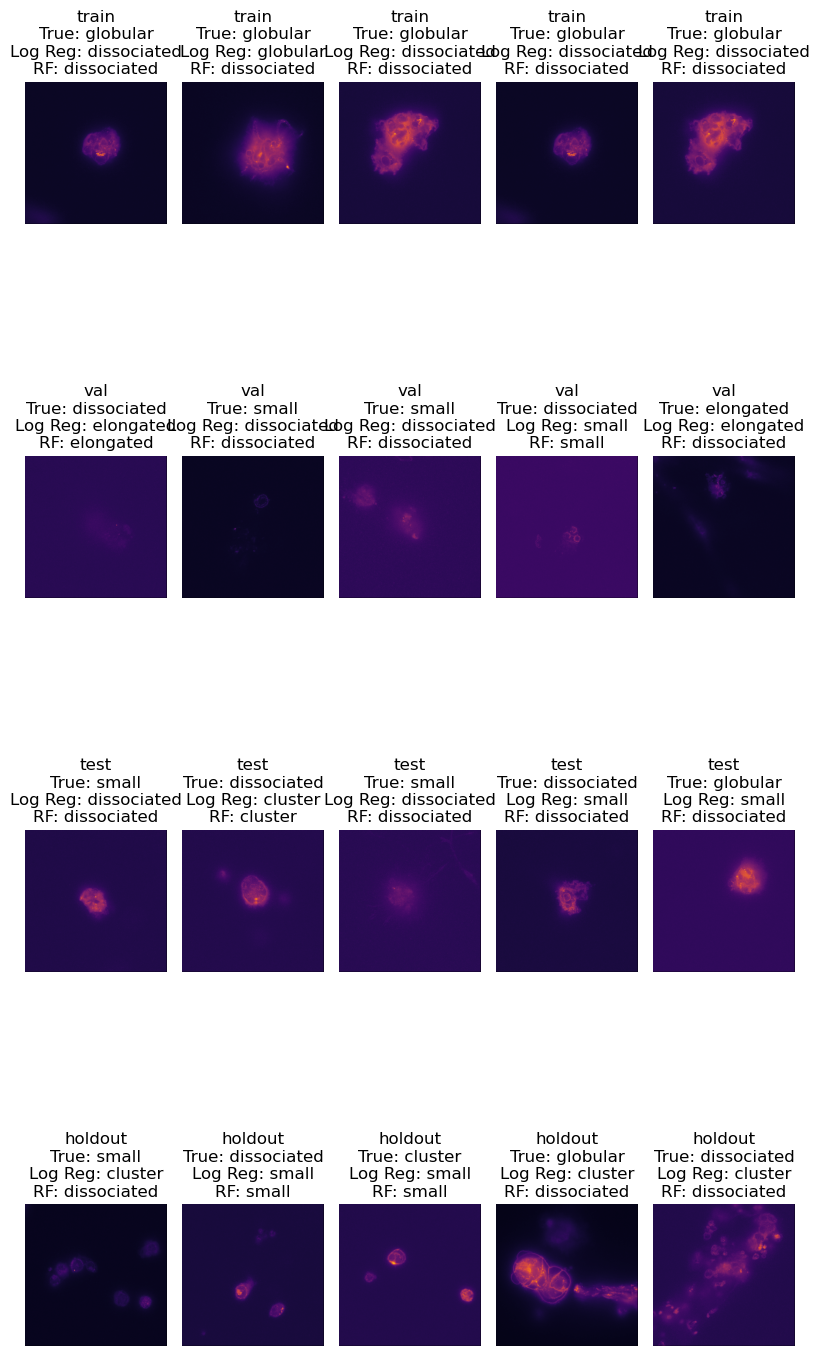

In [ ]:
# plot in a grid with rows as splits and columns as models
splits = ["train", "val", "test", "holdout"]
n_images_to_visualize = 5
fig, axes = plt.subplots(
    len(splits),
    n_images_to_visualize,  # n  images per data split
    figsize=(8, 16),
)
for row_idx, split in enumerate(splits):
    for col_idx in range(
        n_images_to_visualize
    ):  # n_images_to_visualize images per data split
        ax = axes[row_idx, col_idx]
        sample = sampled_wrong_preds_df[(sampled_wrong_preds_df["split"] == split)]
        label = (
            sample["label_name"].iloc[col_idx]
            if not sample.empty and col_idx < len(sample)
            else "N/A"
        )
        log_reg_model_pred = (
            sample["log_reg_prediction"].iloc[col_idx]
            if not sample.empty and col_idx < len(sample)
            else "N/A"
        )
        rf_model_pred = (
            sample["rf_prediction"].iloc[col_idx]
            if not sample.empty and col_idx < len(sample)
            else "N/A"
        )
        if sample.empty or col_idx >= len(sample):
            ax.axis("off")
            continue
        image_path = sample.iloc[col_idx]["image_path"]
        img = read_zstack_image(image_path)
        mid = img[img.shape[0] // 2]
        ax.imshow(mid, cmap="inferno")
        ax.axis("off")
        title = f"{split}\nTrue: {label}\nLog Reg: {log_reg_model_pred}\nRF: {rf_model_pred}"
        ax.set_title(title)
plt.tight_layout()
plt.show()